## The irreducible mass of black holes

This is an example that comes straight out of my research in general relativity:
**Gerosa, Fabbri, Sperhake (2022) "*The irreducible mass and the horizon area of LIGO's black holes*" [arxiv:2202.08848](https://arxiv.org/abs/2202.08848), [CQG 39 (2022) 175008**](https://iopscience.iop.org/article/10.1088/1361-6382/ac8332)
*(some of the calculations here were first worked out by Cecilia Fabbri in her BSc thesis with me).*

### Background

Consider a rotating black hole. In [1969](https://ui.adsabs.harvard.edu/abs/1969NCimR...1..252P/abstract), Roger Penrose discovered that one can extract energy from a rotating black hole:

A rotating black hole has a region called the **ergosphere** where infalling particles can have negative energy relative to an observer at infinity. Penrose imagined a particle entering this region and decaying: half falls in and half escapes, carrying away more energy than the original particle had.

Essentially, we extract mass/energy and angular momentum. However, angular momentum is depleted faster. A series of Penrose processes eventually leaves behind a non-rotating BH with a remnant mass called the **"irreducible mass"**. This result by [Christodoulou (1970)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.25.1596) is the foundation of black-hole thermodynamics and Hawking's area law.

### The Model

For a BH of mass $M$ and dimensionless spin $\chi \in [0,1]$, the irreducible mass is:


$$M_{\rm irr} = M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$

For convenience, let us define:


$$f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$

**Assumptions for our toy model:**

* The spin $\chi$ is **uniformly distributed** between 0 and 1.
* The mass $M$ is **normally distributed** with mean $\mu$ and standard deviation $\sigma$.
* Masses and spins are **uncorrelated**.

---

### Tasks:

1. **Normalization**: Start with $\sigma=0.02$. Set $\mu=1$ in your code (all mass quantities will be in units of $\mu$).
2. **Histogram**: Plot the resulting PDF of $M_{\rm irr}$ using a histogram.
* *Hint*: You don't need the functional form to generate samples!


3. **KDE**: Using the same samples, plot the distribution of $M_{\rm irr}$ using a Kernel Density Estimate (KDE).
4. **KS Test (v. spin function)**: Compute the Kolmogorov-Smirnov (KS) distance between $M_{\rm irr}/\mu$ and $f$ as a function of $\sigma$. Discuss the limits at large and small $\sigma$.
5. **KS Test (v. mass)**: Compute the KS distance between $M_{\rm irr}$ and $M$ as a function of $\sigma$.
* *Hint*: Use `scipy.stats.ks_2samp`.
* *Expected result*: $M_{\rm irr} \sim f$ if $\sigma \ll \mu$ and $M_{\rm irr} \sim M$ if $\sigma \gg \mu$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import uniform
from scipy.stats import ks_2samp
from scipy.integrate import trapezoid

from sklearn.neighbors import KernelDensity
import astropy.visualization.hist

# ── Helper function ──────────────────────────────────────────────────────────
def f_distribution(chi):
    """
    Compute the spin-dependent factor f(chi) = sqrt((1 + sqrt(1 - chi^2)) / 2).
    This factor maps BH mass M and spin chi to the irreducible mass M_irr = M * f(chi).
    """
    return np.sqrt((1 + np.sqrt(1 - chi**2)) / 2)

def irr_mass(M, chi):

    return M * np.sqrt( ( 1 + np.sqrt( 1 - chi ** 2) ) / 2)


# ── Model parameters ─────────────────────────────────────────────────────────
mu    = 1       # Mean BH mass (all masses expressed in units of mu)
sigma = 0.02    # Standard deviation of the mass distribution
N    = 10_000  # Number of Monte-Carlo samples


### Histogram of $M_{\rm irr}$

Plot the resulting PDF of $M_{\rm irr}$ using a histogram. I've used two automatic binning rules:
- **Scott's rule**: bin width $\propto \sigma \cdot n^{-1/3}$, optimal for normal distributions.
- **Freedman–Diaconis rule**: bin width $\propto \text{IQR} \cdot n^{-1/3}$, more robust to outliers.

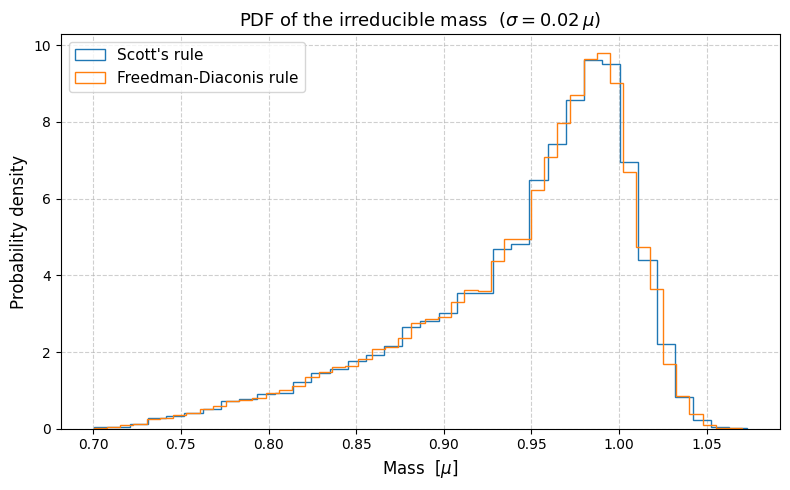

In [8]:
# ── Draw samples ──────────────────────────────────────────────────────────
# Mass M ~ Normal(mu, sigma)
masses_vector = np.random.normal(mu, sigma, N)

# Dimensionless spin chi ~ Uniform(0, 1)
chi_vector = np.random.uniform(0, 1, N)

# Irreducible mass M_irr = M * f(chi)
M_irr = f_distribution(chi_vector) * masses_vector

# ── Histogram of M_irr ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
astropy.visualization.hist(M_irr, bins="scott", histtype="step",density=True, label="Scott's rule")
astropy.visualization.hist(M_irr, bins="freedman", histtype="step",density=True, label = "Freedman-Diaconis rule")

ax.set_title("PDF of the irreducible mass  ($\\sigma = 0.02\\,\\mu$)", fontsize=13)
ax.set_xlabel(r"Mass  [$\mu$]", fontsize=12)
ax.set_ylabel("Probability density", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### KDE distribution of $M_{irr}$

In [9]:
x_i = np.linspace(M_irr.min(), M_irr.max(), N)

def kde_sklearn(data, bandwidth, kernel):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x_i[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

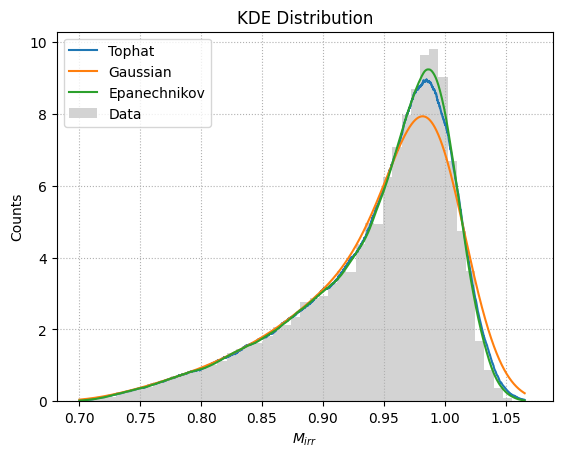

In [10]:
PDF_TH = kde_sklearn(M_irr, sigma, kernel="tophat") 
PDF_G = kde_sklearn(M_irr, sigma, kernel="gaussian") 
PDF_E = kde_sklearn(M_irr, sigma, kernel="epanechnikov") 

plt.plot(x_i, PDF_TH, label="Tophat")
plt.plot(x_i, PDF_G, label="Gaussian")
plt.plot(x_i, PDF_E, label="Epanechnikov")
astropy.visualization.hist(M_irr, bins="freedman", color ="lightgray", density=True, label = "Data")


plt.title("KDE Distribution")
plt.xlabel("$M_{irr}$")
plt.ylabel("Counts")
plt.legend()
plt.grid(linestyle = ":")
plt.show()

### KS distances as a function of sigma

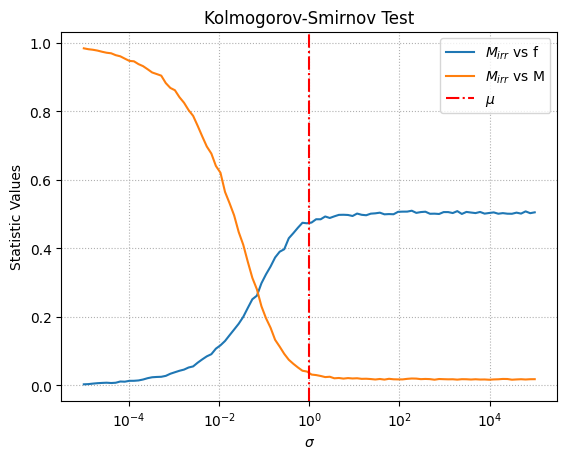

In [11]:
ks_f = []
ks_M = []
sigma_vec = np.logspace(-5, 5, 100)

for s in sigma_vec:
    M = norm.rvs(mu, s, N)
    chi = uniform.rvs(0, 1, N)

    ks_f_stat, _ = ks_2samp(f_distribution(chi), irr_mass(M, chi))
    ks_M_stat, _ = ks_2samp(M, irr_mass(M, chi))

    ks_f.append(ks_f_stat)
    ks_M.append(ks_M_stat)

plt.plot(sigma_vec, ks_f, label=r"$M_{irr}$ vs f")
plt.plot(sigma_vec, ks_M, label=r"$M_{irr}$ vs M")
plt.axvline(mu, linestyle = '-.', c = 'r', label = r"$\mu$")
plt.semilogx()

plt.title("Kolmogorov-Smirnov Test")
plt.xlabel(r"$\sigma$")
plt.ylabel("Statistic Values")
plt.legend()
plt.grid(linestyle = ":")
plt.show()

The graph shows two different behaviours: 

- On the right we have that the most probable model is for $M_{irr}$ to be distributed like $f$ ( ${\mu \gg \sigma}$);
- On the left we have that the most probable model is for $M_{irr}$ to be distributed like $M$ ( ${\sigma}\ll \mu$);


### Check with the Analitic Distribution


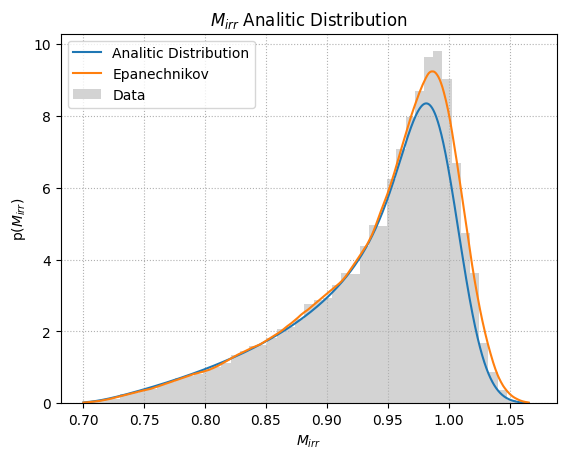

In [12]:
def integral(Mirr, f, mu, sigma):
    return np.exp( -( Mirr/f - mu )**2 / ( 2 * sigma**2 ) ) * ( ( 2 * f**2 - 1 ) / ( f * np.sqrt( 1 - f**2 ) ) )
f_integral = np.linspace( 1/np.sqrt(2), 0.999, N)

pdf_Mirr = np.sqrt( 2 / np.pi ) / sigma * np.array([
    trapezoid(integral(x, f_integral, mu, sigma), dx = f_integral[1]-f_integral[0]) for x in x_i
])

plt.plot(x_i, pdf_Mirr, label = "Analitic Distribution")
plt.plot(x_i, PDF_E, label="Epanechnikov")
astropy.visualization.hist(M_irr, bins="freedman", color ="lightgray", density=True, label = "Data")

plt.title("$M_{irr}$ Analitic Distribution")
plt.xlabel("$M_{irr}$")
plt.ylabel("p($M_{irr}$)")
plt.legend()
plt.grid(linestyle = ":")
plt.show()